Tested with following versions:



*   Python 3.11.13
*   pandas version: 2.2.2
*   matplotlib version: 3.10.0
*   scikit-learn version: 1.6.1
*   numpy version: 2.0.2


In [1]:
# Import relevant packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Import data from dropbox
!wget -O AAPL_NVDA_2024.xlsx https://www.dropbox.com/scl/fi/rr3h3vnj6n6uswm1yctzu/AAPL_NVDA_2024.xlsx?rlkey=narlopxxwb6mtxalgus7zntt6&dl=0

# Import
retdata = pd.read_excel("AAPL_NVDA_2024.xlsx")
print(retdata.head())

--2025-08-15 14:28:25--  https://www.dropbox.com/scl/fi/rr3h3vnj6n6uswm1yctzu/AAPL_NVDA_2024.xlsx?rlkey=narlopxxwb6mtxalgus7zntt6
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc762e0d3715d35734bf101cf466.dl.dropboxusercontent.com/cd/0/inline/Cvc3uw47wR8gaQMW9ZIySQf5Q6JRTHYrndBZNOP-icBk_sMZhGHdhq8pLgtPH7cHsjRFXH6FF670Ub4dLSQD7BSo3YHn6R212syu4kFqpD0QWQR_L7lEOuxRTsN1mTuj4YWO7d4R5BGPTWbpPu157guo/file# [following]
--2025-08-15 14:28:25--  https://uc762e0d3715d35734bf101cf466.dl.dropboxusercontent.com/cd/0/inline/Cvc3uw47wR8gaQMW9ZIySQf5Q6JRTHYrndBZNOP-icBk_sMZhGHdhq8pLgtPH7cHsjRFXH6FF670Ub4dLSQD7BSo3YHn6R212syu4kFqpD0QWQR_L7lEOuxRTsN1mTuj4YWO7d4R5BGPTWbpPu157guo/file
Resolving uc762e0d3715d35734bf101cf466.dl.dropboxusercontent.com (uc762e0d3715d35734bf101cf466.dl.dropboxusercontent.com)... 162.125.1.15,

In [3]:
# For simplicity, rename the columns to AAPL and NVDA
retdata.columns = ["Date", "AAPL", "NVDA"]

# Just keep the return columns
retdata = retdata[["AAPL","NVDA"]]
print(retdata.head())


       AAPL      NVDA
0 -0.107697 -0.019975
1  0.057311  0.176115
2  0.019953 -0.025571
3  0.099396  0.031267
4  0.078293  0.033297


In [4]:
# Extract the two principal components
pca = PCA(n_components=2)
ret_pca = pca.fit_transform(retdata)
ret_pca_directions = pca.components_
ret_pca_var = pca.explained_variance_
ret_pca_variance = pca.explained_variance_ratio_

# For seeing loadings
loadings = pd.DataFrame(ret_pca_directions, columns=retdata.columns,
                        index=["PC1","PC2"])

# Add explained variance to loadings data frame
loadings["Fraction Explained Variance"] = ret_pca_variance

print(loadings)

         AAPL      NVDA  Fraction Explained Variance
PC1  0.384472  0.923137                     0.834072
PC2  0.923137 -0.384472                     0.165928


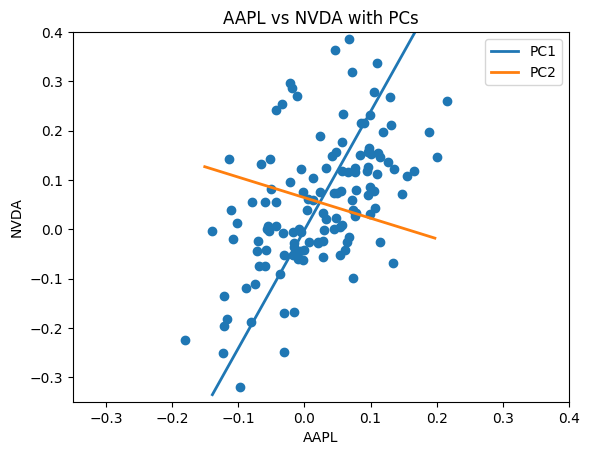

In [5]:
ret_mean = retdata.mean()

# Plot PC directions on scatter plot of AAPL vs NVDA
plt.scatter(retdata['AAPL'], retdata['NVDA'])
# Set limits to have same range for AAPL and NVDA
plt.xlim([-0.35,0.4])
plt.ylim([-0.35,0.4])
# Add principal component directions to scatterplot
# Scale according to component standard deviation
for i in range(2):
    v = 3*np.sqrt(ret_pca_var[i]) * ret_pca_directions[i]
    x_vals = [ret_mean.iloc[0] - v[0], ret_mean.iloc[0] + v[0]]
    y_vals = [ret_mean.iloc[1] - v[1], ret_mean.iloc[1] + v[1]]
    plt.plot(x_vals, y_vals, linewidth=2, label=f"PC{i+1}")

plt.legend()
plt.xlabel('AAPL')
plt.ylabel('NVDA')
plt.title('AAPL vs NVDA with PCs')
plt.show()



In [6]:
# Repeat with standardized data
retdata_std = StandardScaler().fit_transform(retdata)
ret_pca_std = pca.fit_transform(retdata_std)
ret_pca_directions_std = pca.components_
ret_pca_var_std = pca.explained_variance_
ret_pca_variance_std = pca.explained_variance_ratio_

# For seeing loadings
loadings_std = pd.DataFrame(ret_pca_directions_std, columns=retdata.columns,
                        index=["PC1","PC2"])

# Add explained variance to loadings data frame
loadings_std["Fraction Explained Variance"] = ret_pca_variance_std

print(loadings_std)

         AAPL      NVDA  Fraction Explained Variance
PC1  0.707107  0.707107                      0.76876
PC2  0.707107 -0.707107                      0.23124


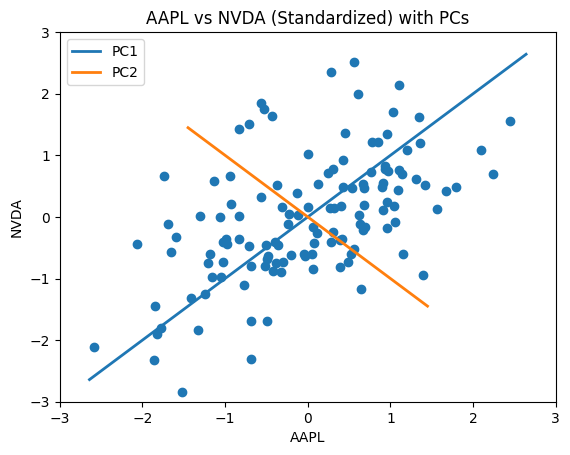

In [7]:
# Plot PC directions on scatter plot of standardized AAPL vs NVDA
plt.scatter(retdata_std[:,0], retdata_std[:,1])
# Add principal component directions to scatterplot
# Scale according to component standard deviation
for i in range(2):
    v = 3*np.sqrt(ret_pca_var_std[i])*ret_pca_directions_std[i]
    x_vals = [-v[0], v[0]]
    y_vals = [-v[1], v[1]]
    plt.plot(x_vals, y_vals, linewidth=2, label=f"PC{i+1}")
# Set xlim and ylim to +/-3
plt.xlim([-3,3])
plt.ylim([-3,3])
plt.legend()
plt.xlabel('AAPL')
plt.ylabel('NVDA')
plt.title('AAPL vs NVDA (Standardized) with PCs')
plt.show()